In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


### Load all CSV files into organized DataFrames

I will load all the available `.csv` files into a Python dictionary, where each key will be a simplified name of the dataset (e.g., `customers`, `orders`) and the value will be the corresponding pandas DataFrame. This makes it easy to access and manage all your data.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

In [ ]:
# Define the date columns for parsing based on typical Olist datasets
date_cols = {
    'orders': ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
    'items': ['shipping_limit_date'],
    'reviews': ['review_creation_date', 'review_answer_timestamp']
}

# Mapping of desired DataFrame names to actual file names
file_map = {
    'orders': 'olist_orders_dataset.csv',
    'items': 'olist_order_items_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'geo': 'olist_geolocation_dataset.csv',
    'transl': 'product_category_name_translation.csv' # Using 'transl' as in user's example
}

# Dictionary to store all DataFrames
dfs = {}

print("Loading all CSV files into DataFrames with specified names and parsing options...")

for df_name, file_name in file_map.items():
    file_path = os.path.join(path, file_name)

    # Determine parse_dates argument from date_cols
    parse_dates_arg = date_cols.get(df_name, None)

    try:
        if parse_dates_arg:
            dfs[df_name] = pd.read_csv(file_path, parse_dates=parse_dates_arg)
        else:
            dfs[df_name] = pd.read_csv(file_path)
        print(f"Loaded '{file_name}' as '{df_name}' DataFrame.")
    except Exception as e:
        print(f"Error loading '{file_name}' as '{df_name}': {e}")

print("\nAll DataFrames loaded successfully!")
print("You can access them via the 'dfs' dictionary. For example, 'dfs['customers']'.")

# Print summary as requested by the user
print('\nFicheiros carregados:')
for name, df in dfs.items():
    print(f'  {name:12s}: {df.shape[0]:6d} linhas x {df.shape[1]} colunas')

# Display the head of a couple of DataFrames for demonstration
print("\nFirst 5 rows of 'customers' DataFrame:")
display(dfs['customers'].head())

print("\nFirst 5 rows of 'orders' DataFrame:")
display(dfs['orders'].head())

Loading all CSV files into DataFrames with specified names and parsing options...
Loaded 'olist_orders_dataset.csv' as 'orders' DataFrame.
Loaded 'olist_order_items_dataset.csv' as 'items' DataFrame.
Loaded 'olist_order_payments_dataset.csv' as 'payments' DataFrame.
Loaded 'olist_order_reviews_dataset.csv' as 'reviews' DataFrame.
Loaded 'olist_customers_dataset.csv' as 'customers' DataFrame.
Loaded 'olist_sellers_dataset.csv' as 'sellers' DataFrame.
Loaded 'olist_products_dataset.csv' as 'products' DataFrame.
Loaded 'olist_geolocation_dataset.csv' as 'geo' DataFrame.
Loaded 'product_category_name_translation.csv' as 'transl' DataFrame.

All DataFrames loaded successfully!
You can access them via the 'dfs' dictionary. For example, 'dfs['customers']'.

Ficheiros carregados:
  orders      :  99441 linhas x 8 colunas
  items       : 112650 linhas x 7 colunas
  payments    : 103886 linhas x 5 colunas
  reviews     :  99224 linhas x 7 colunas
  customers   :  99441 linhas x 5 colunas
  selle

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



First 5 rows of 'orders' DataFrame:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [ ]:
for name, df in dfs.items():
    print(f'  {name:12s}: {df.shape[0]:6d} linhas x {df.shape[1]} colunas')

  orders      :  99441 linhas x 8 colunas
  items       : 112650 linhas x 7 colunas
  payments    : 103886 linhas x 5 colunas
  reviews     :  99224 linhas x 7 colunas
  customers   :  99441 linhas x 5 colunas
  sellers     :   3095 linhas x 4 colunas
  products    :  32951 linhas x 9 colunas
  geo         : 1000163 linhas x 5 colunas
  transl      :     71 linhas x 2 colunas


---
## 1. Qualidade dos dados
> **Apontamento para o relatório:** Esta secção documenta os problemas encontrados nas fontes de dados e as decisões tomadas no ETL.


### 1.1 Nulos e duplicados — visão geral

In [ ]:
def quality_report(df, name):
    nulls = df.isnull().sum()
    pct   = (nulls / len(df) * 100).round(1)
    dups  = df.duplicated().sum()
    print(f'\n{"="*60}')
    print(f'  {name}  ({df.shape[0]} linhas x {df.shape[1]} colunas)')
    print(f'{"="*60}')
    for col in df.columns:
        flag = '  <-- NULOS' if nulls[col] > 0 else ''
        print(f'  {col:42s} {str(df[col].dtype):10s}  nulos: {nulls[col]:3d} ({pct[col]:5.1f}%){flag}')
    flag_dup = '  <-- ATENÇÃO' if dups > 0 else ''
    print(f'  Duplicados: {dups}{flag_dup}')

for name, df in dfs.items():
    quality_report(df, name.upper())


  ORDERS  (99441 linhas x 8 colunas)
  order_id                                   object      nulos:   0 (  0.0%)
  customer_id                                object      nulos:   0 (  0.0%)
  order_status                               object      nulos:   0 (  0.0%)
  order_purchase_timestamp                   datetime64[ns]  nulos:   0 (  0.0%)
  order_approved_at                          datetime64[ns]  nulos: 160 (  0.2%)  <-- NULOS
  order_delivered_carrier_date               datetime64[ns]  nulos: 1783 (  1.8%)  <-- NULOS
  order_delivered_customer_date              datetime64[ns]  nulos: 2965 (  3.0%)  <-- NULOS
  order_estimated_delivery_date              datetime64[ns]  nulos:   0 (  0.0%)
  Duplicados: 0

  ITEMS  (112650 linhas x 7 colunas)
  order_id                                   object      nulos:   0 (  0.0%)
  order_item_id                              int64       nulos:   0 (  0.0%)
  product_id                                 object      nulos:   0 (  0.0%)
  sell

### 1.2 Análise detalhada — orders com datas nulas

In [ ]:
# Perceber porquê há datas de entrega nulas
print('=== Ordens com order_delivered_customer_date nula ===')
mask = dfs['orders']['order_delivered_customer_date'].isnull()
cols = ['order_id','order_status','order_delivered_carrier_date',
        'order_delivered_customer_date','order_estimated_delivery_date']
print(dfs['orders'][mask][cols].to_string(index=False))

print('\n=== Distribuição de order_status ===')
print(dfs['orders']['order_status'].value_counts().to_string())

=== Ordens com order_delivered_customer_date nula ===
                        order_id order_status order_delivered_carrier_date order_delivered_customer_date order_estimated_delivery_date
136cce7faa42fdb2cefd53fdc79a6098     invoiced                          NaT                           NaT                    2017-05-09
ee64d42b8cf066f35eac1cf57de1aa85      shipped          2018-06-05 14:32:00                           NaT                    2018-06-28
0760a852e4e9d89eb77bf631eaaf1c84     invoiced                          NaT                           NaT                    2018-08-21
15bed8e2fec7fdbadb186b57c46c92f2   processing                          NaT                           NaT                    2017-10-03
6942b8da583c2f9957e990d028607019      shipped          2018-01-11 19:39:23                           NaT                    2018-02-07
36530871a5e80138db53bcfd8a104d90      shipped          2017-05-11 13:21:47                           NaT                    2017-06-08
4

### 1.3 Análise detalhada — reviews com campos nulos

In [ ]:
print('=== Nulos em reviews ===')
for col in ['review_comment_title','review_comment_message','review_score']:
    n = dfs['reviews'][col].isnull().sum()
    p = n/len(dfs['reviews'])*100
    print(f'  {col:30s}: {n:3d} nulos ({p:.0f}%)')

=== Nulos em reviews ===
  review_comment_title          : 87656 nulos (88%)
  review_comment_message        : 58247 nulos (59%)
  review_score                  :   0 nulos (0%)


### 1.4 Análise detalhada — geolocation com duplicados

In [ ]:
print('=== Linhas duplicadas em geolocation ===')
dups_count = dfs['geo'].duplicated().sum()
print(f'Total de duplicados: {dups_count}')
if dups_count > 0:
    print('Exemplo de linhas duplicadas (primeiras 5):')
    display(dfs['geo'][dfs['geo'].duplicated()].head())

=== Linhas duplicadas em geolocation ===
Total de duplicados: 261831
Exemplo de linhas duplicadas (primeiras 5):


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP


### 1.5 Consistência entre tabelas (chaves estrangeiras)

In [ ]:
print('=== Verificação de chaves (nota: amostra _small pode ter orphans) ===\n')

checks = [
    (dfs['items'],    'order_id',    dfs['orders'],    'order_id',    'items -> orders'),
    (dfs['items'],    'product_id',  dfs['products'],  'product_id',  'items -> products'),
    (dfs['items'],    'seller_id',   dfs['sellers'],   'seller_id',   'items -> sellers'),
    (dfs['orders'],   'customer_id', dfs['customers'], 'customer_id', 'orders -> customers'),
    (dfs['reviews'],  'order_id',    dfs['orders'],    'order_id',    'reviews -> orders'),
    (dfs['payments'], 'order_id',    dfs['orders'],    'order_id',    'payments -> orders'),
]

for left_df, left_key, right_df, right_key, label in checks:
    orphans = left_df[~left_df[left_key].isin(right_df[right_key])]
    status  = 'OK' if len(orphans) == 0 else f'ORPHANS: {len(orphans)}'
    print(f'  {label:30s} -> {status}')

=== Verificação de chaves (nota: amostra _small pode ter orphans) ===

  items -> orders                -> OK
  items -> products              -> OK
  items -> sellers               -> OK
  orders -> customers            -> OK
  reviews -> orders              -> OK
  payments -> orders             -> OK


---
## 2. Validação dos campos calculados do star schema
> Estes campos **não existem nos CSVs** — são criados no Pentaho. Validamos aqui a lógica antes de implementar.


### 2.1 delay_days, actual_delivery_days, is_late_delivery

In [ ]:
df_calc = dfs['orders'].copy()

df_calc['actual_delivery_days'] = (
    df_calc['order_delivered_customer_date'] - df_calc['order_purchase_timestamp']
).dt.days

df_calc['delay_days'] = (
    df_calc['order_delivered_customer_date'] - dfs['orders']['order_estimated_delivery_date']
).dt.days

df_calc['is_late_delivery'] = (df_calc['delay_days'] > 0).astype('Int64')

print('=== Estatísticas dos campos calculados ===')
print(df_calc[['actual_delivery_days','delay_days','is_late_delivery']].describe().round(2))

n_late  = df_calc['is_late_delivery'].sum()
n_total = df_calc['is_late_delivery'].notna().sum()
print(f'\nEncomendas atrasadas: {n_late} / {n_total} ({n_late/n_total*100:.1f}%)')
print(f'Encomendas sem data de entrega (NULL): {df_calc["is_late_delivery"].isna().sum()}')

=== Estatísticas dos campos calculados ===
       actual_delivery_days  delay_days  is_late_delivery
count              96476.00    96476.00           99441.0
mean                  12.09      -11.88              0.07
std                    9.55       10.18              0.25
min                    0.00     -147.00               0.0
25%                    6.00      -17.00               0.0
50%                   10.00      -12.00               0.0
75%                   15.00       -7.00               0.0
max                  209.00      188.00               1.0

Encomendas atrasadas: 6535 / 99441 (6.6%)
Encomendas sem data de entrega (NULL): 0


### 2.2 is_negative_review

=== Distribuição review_score ===
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Reviews negativas (score 1 ou 2): 14575 / 99224 (14.7%)


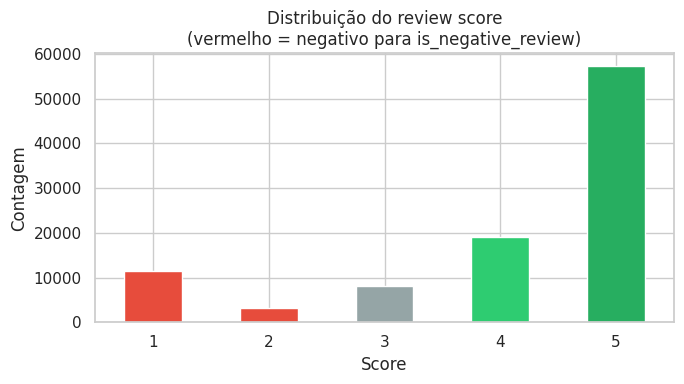

In [ ]:
dfs['reviews']['is_negative_review'] = (dfs['reviews']['review_score'] <= 2).astype(int)

print('=== Distribuição review_score ===')
print(dfs['reviews']['review_score'].value_counts().sort_index())
n_neg = dfs['reviews']['is_negative_review'].sum()
print(f'\nReviews negativas (score 1 ou 2): {n_neg} / {len(dfs['reviews'])} ({n_neg/len(dfs['reviews'])*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#e74c3c','#e74c3c','#95a5a6','#2ecc71','#27ae60']
dfs['reviews']['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Distribuição do review score\n(vermelho = negativo para is_negative_review)')
ax.set_xlabel('Score'); ax.set_ylabel('Contagem')
ax.set_xticklabels(['1','2','3','4','5'], rotation=0)
plt.tight_layout(); plt.show()

### 2.3 Pagamentos — lógica de agregação

In [ ]:
print('=== Tipos de pagamento ===')
print(dfs['payments']['payment_type'].value_counts())

print('\n=== Ordens com múltiplos métodos de pagamento ===')
multi = dfs['payments'][dfs['payments']['payment_sequential'] > 1]
print(f'Registos com payment_sequential > 1: {len(multi)}')
print(f'Ordens afectadas: {multi["order_id"].nunique()}')

=== Tipos de pagamento ===
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

=== Ordens com múltiplos métodos de pagamento ===
Registos com payment_sequential > 1: 4526
Ordens afectadas: 3039


---
## 3. Análise prévia por Big Question
> Resultados **não representativos** com os ficheiros _small (50 linhas).  
> Servem para **validar a lógica** antes de usar o dataset completo.


### Q1 — Regiões e categorias: volume, atraso e review score
*Descritivo — resposta no Tableau após carga do DW*

In [ ]:
# Construir dataframe integrado para Q1
df_q1 = (dfs['items']
    .merge(dfs['orders'][['order_id','customer_id','order_purchase_timestamp',
                   'order_delivered_customer_date',
                   'order_estimated_delivery_date']], on='order_id', how='left')
    .merge(dfs['customers'][['customer_id','customer_state']], on='customer_id', how='left')
    .merge(dfs['reviews'][['order_id','review_score','is_negative_review']], on='order_id', how='left')
    .merge(dfs['products'][['product_id','product_category_name']], on='product_id', how='left')
    .merge(dfs['transl'], left_on='product_category_name', right_on='product_category_name', how='left')
)

df_q1['delay_days'] = (
    df_q1['order_delivered_customer_date'] - df_q1['order_estimated_delivery_date']
).dt.days

print('=== Métricas por estado do cliente ===')
q1_state = df_q1.groupby('customer_state', dropna=True).agg(
    n_encomendas  = ('order_id','count'),
    receita_total = ('price','sum'),
    atraso_medio  = ('delay_days','mean'),
    score_medio   = ('review_score','mean'),
).round(2).sort_values('receita_total', ascending=False)
print(q1_state.to_string())

print('\n=== Métricas por categoria (EN) ===')
q1_cat = df_q1.groupby('product_category_name_english', dropna=True).agg(
    n_encomendas  = ('order_id','count'),
    receita_total = ('price','sum'),
    atraso_medio  = ('delay_days','mean'),
    score_medio   = ('review_score','mean'),
).round(2).sort_values('receita_total', ascending=False)
print(q1_cat.head(10).to_string())

=== Métricas por estado do cliente ===
                n_encomendas  receita_total  atraso_medio  score_medio
customer_state                                                        
SP                     47720     5228869.17        -11.22         4.13
RJ                     14668     1831678.85        -12.00         3.81
MG                     13209     1591518.47        -13.36         4.09
RS                      6287      754250.33        -14.15         4.05
PR                      5764      685911.51        -13.47         4.10
SC                      4191      522120.11        -11.56         4.00
BA                      3819      513182.78        -10.98         3.81
DF                      2433      304658.17        -12.18         4.01
GO                      2353      297535.49        -12.32         3.99
ES                      2269      275910.68        -10.66         3.99
PE                      1818      263801.64        -13.50         3.96
CE                      1483      2279

### Q2 — Atraso + portes vs. avaliação negativa


=== Correlação com is_negative_review ===
                    delay_days  freight_value  is_negative_review
delay_days               1.000         -0.041               0.217
freight_value           -0.041          1.000               0.029
is_negative_review       0.217          0.029               1.000

=== Score médio: entregues a tempo vs atrasadas ===
         media  contagem
is_late                 
False    4.207    102899
True     2.257      7113


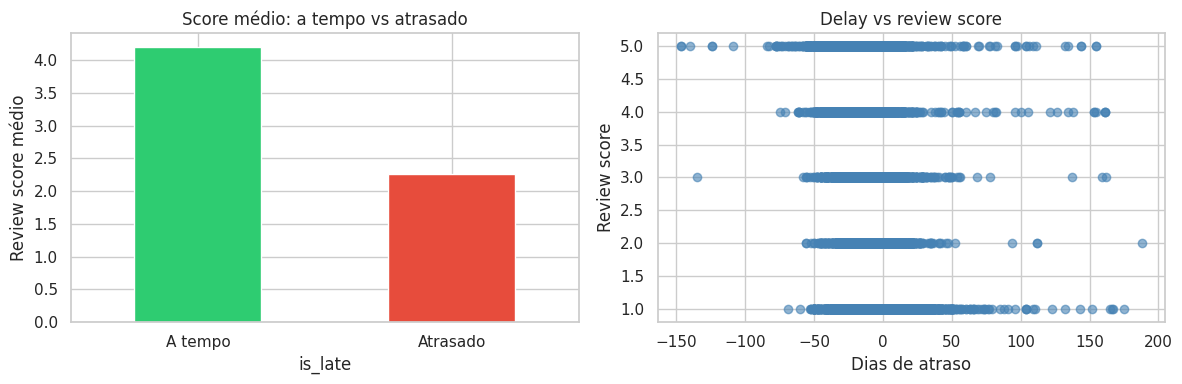

In [ ]:
df_q2 = (dfs['orders']
    .merge(dfs['items'][['order_id','freight_value']], on='order_id', how='left')
    .merge(dfs['reviews'][['order_id','review_score','is_negative_review']], on='order_id', how='left')
)

df_q2['delay_days'] = (
    df_q2['order_delivered_customer_date'] - df_q2['order_estimated_delivery_date']
).dt.days

df_q2_clean = df_q2.dropna(subset=['delay_days','review_score','freight_value'])

print('=== Correlação com is_negative_review ===')
corr_cols = ['delay_days','freight_value','is_negative_review']
print(df_q2_clean[corr_cols].corr().round(3))

print('\n=== Score médio: entregues a tempo vs atrasadas ===')
df_q2_clean['is_late'] = (df_q2_clean['delay_days'] > 0)
print(df_q2_clean.groupby('is_late')['review_score'].agg(
    media='mean', contagem='count').round(3).to_string())

if len(df_q2_clean) >= 4:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    df_q2_clean.groupby('is_late')['review_score'].mean().plot(
        kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='white')
    axes[0].set_title('Score médio: a tempo vs atrasado')
    axes[0].set_xticklabels(['A tempo','Atrasado'], rotation=0)
    axes[0].set_ylabel('Review score médio')

    axes[1].scatter(df_q2_clean['delay_days'], df_q2_clean['review_score'],
                    alpha=0.6, color='steelblue')
    axes[1].set_title('Delay vs review score')
    axes[1].set_xlabel('Dias de atraso'); axes[1].set_ylabel('Review score')

    plt.tight_layout(); plt.show()
else:
    print('Amostras insuficientes para gráfico (dataset de teste).')


### Q3 — Desempenho dos vendedores
*Diagnóstico — ranking e fatores explicativos*

In [ ]:
df_q3 = (dfs['items']
    .merge(dfs['orders'][['order_id','order_delivered_customer_date',
                   'order_estimated_delivery_date']], on='order_id', how='left')
    .merge(dfs['reviews'][['order_id','review_score']], on='order_id', how='left')
    .merge(dfs['sellers'][['seller_id','seller_state']], on='seller_id', how='left')
    .merge(dfs['products'][['product_id','product_category_name']], on='product_id', how='left')
)

df_q3['delay_days'] = (
    df_q3['order_delivered_customer_date'] - df_q3['order_estimated_delivery_date']
).dt.days

seller_stats = df_q3.groupby('seller_id').agg(
    n_encomendas  = ('order_id','count'),
    score_medio   = ('review_score','mean'),
    atraso_medio  = ('delay_days','mean'),
    receita_total = ('price','sum'),
    estado        = ('seller_state','first'),
).round(2).sort_values('n_encomendas', ascending=False)

print('=== Top vendedores (por nº de encomendas) ===')
print(seller_stats.head(8).to_string())

print('\n=== Vendedor com melhor score ===')
print(seller_stats.sort_values('score_medio', ascending=False).head(3).to_string())

print('\n=== Vendedor com pior score ===')
print(seller_stats.sort_values('score_medio').head(3).to_string())

=== Top vendedores (por nº de encomendas) ===
                                  n_encomendas  score_medio  atraso_medio  receita_total estado
seller_id                                                                                      
6560211a19b47992c3666cc44a7e94c0          2039         3.91        -11.72      123585.82     SP
4a3ca9315b744ce9f8e9374361493884          2009         3.80         -9.66      202999.12     SP
1f50f920176fa81dab994f9023523100          1940         3.98        -10.83      107431.41     SP
cc419e0650a3c5ba77189a1882b7556a          1819         4.07        -13.03      106555.98     SP
da8622b14eb17ae2831f4ac5b9dab84a          1574         4.07        -11.31      162723.37     SP
955fee9216a65b617aa5c0531780ce60          1501         4.05        -10.33      135241.70     SP
1025f0e2d44d7041d6cf58b6550e0bfa          1443         3.85        -11.13      140513.14     SP
7c67e1448b00f6e969d365cea6b010ab          1375         3.35        -11.50      189417.67  

### Q4 — Variáveis preditivas para avaliação negativa
*Preditivo — análise de poder discriminativo*

In [ ]:
# Dataset para classificação (Q4)
df_q4 = (dfs['items']
    .merge(dfs['orders'][['order_id','customer_id',
                   'order_delivered_customer_date',
                   'order_estimated_delivery_date']], on='order_id', how='left')
    .merge(dfs['payments'][['order_id','payment_type','payment_installments']], on='order_id', how='left')
    .merge(dfs['reviews'][['order_id','review_score','is_negative_review']], on='order_id', how='left')
    .merge(dfs['customers'][['customer_id','customer_state']], on='customer_id', how='left')
    .merge(dfs['sellers'][['seller_id','seller_state']], on='seller_id', how='left')
    .merge(dfs['products'][['product_id','product_weight_g']], on='product_id', how='left')
)

df_q4['delay_days'] = (
    df_q4['order_delivered_customer_date'] - df_q4['order_estimated_delivery_date']
).dt.days

print('=== Features numéricas disponíveis para Q4 (poder preditivo) ===')
features_num = ['price','freight_value','payment_installments','product_weight_g','delay_days']
df_q4_clean  = df_q4.dropna(subset=features_num + ['is_negative_review'])

print(f'Registos disponíveis para treino: {len(df_q4_clean)}')
print('\nCorrelação com is_negative_review:')
corrs = df_q4_clean[features_num + ['is_negative_review']].corr()['is_negative_review']
print(corrs.drop('is_negative_review').sort_values(key=abs, ascending=False).round(3).to_string())

=== Features numéricas disponíveis para Q4 (poder preditivo) ===
Registos disponíveis para treino: 114838

Correlação com is_negative_review:
delay_days              0.216
payment_installments    0.047
freight_value           0.029
product_weight_g        0.022
price                   0.004


### Q5 — Estimativa de tempo de entrega
*Prescritivo — regressão + regra de decisão*

In [ ]:
# Dataset para regressão (Q5)
df_q5 = dfs['orders'].copy()
df_q5['actual_delivery_days'] = (
    df_q5['order_delivered_customer_date'] - df_q5['order_purchase_timestamp']
).dt.days
df_q5['estimated_days'] = (
    df_q5['order_estimated_delivery_date'] - df_q5['order_purchase_timestamp']
).dt.days

df_q5_clean = df_q5.dropna(subset=['actual_delivery_days','estimated_days'])

print('=== Actual vs Estimated delivery days ===')
print(df_q5_clean[['actual_delivery_days','estimated_days']].describe().round(2))

print('\n=== Distribuição do erro (actual - estimated) ===')
df_q5_clean['erro_dias'] = df_q5_clean['actual_delivery_days'] - df_q5_clean['estimated_days']
print(df_q5_clean['erro_dias'].describe().round(2))

=== Actual vs Estimated delivery days ===
       actual_delivery_days  estimated_days
count              96476.00        96476.00
mean                  12.09           23.37
std                    9.55            8.76
min                    0.00            2.00
25%                    6.00           18.00
50%                   10.00           23.00
75%                   15.00           28.00
max                  209.00          155.00

=== Distribuição do erro (actual - estimated) ===
count    96476.00
mean       -11.28
std         10.19
min       -146.00
25%        -16.00
50%        -12.00
75%         -7.00
max        189.00
Name: erro_dias, dtype: float64


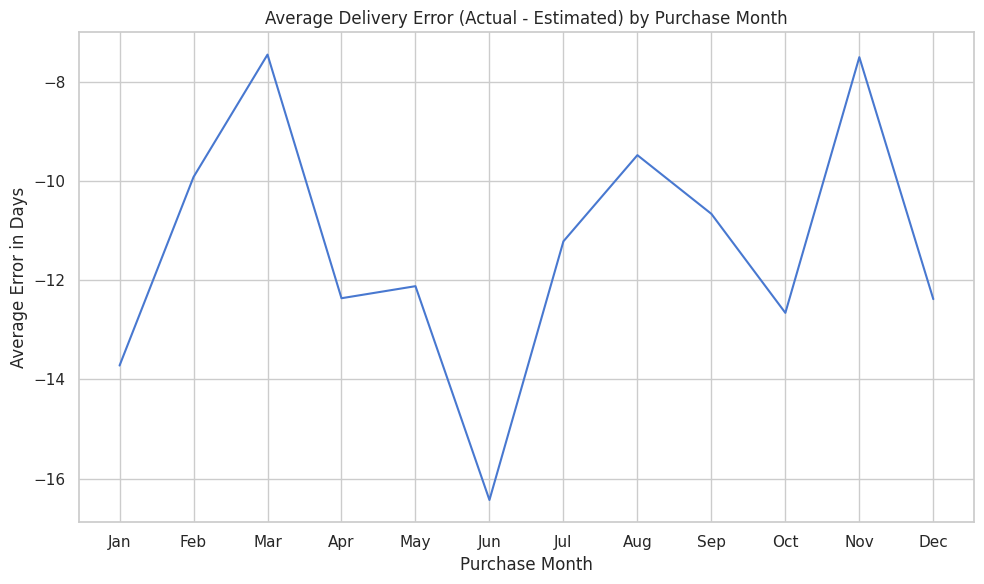

In [ ]:
df_q5_clean['purchase_month'] = df_q5_clean['order_purchase_timestamp'].dt.month

monthly_delay = df_q5_clean.groupby('purchase_month')['erro_dias'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='purchase_month', y='erro_dias', data=monthly_delay)
plt.title('Average Delivery Error (Actual - Estimated) by Purchase Month')
plt.xlabel('Purchase Month')
plt.ylabel('Average Error in Days')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
min_date = dfs['orders']['order_purchase_timestamp'].min()
max_date = dfs['orders']['order_purchase_timestamp'].max()
print(f"O range temporal dos dados é de {min_date.strftime('%B %Y')} a {max_date.strftime('%B %Y')}.")

O range temporal dos dados é de September 2016 a October 2018.


### Q6 — Grupos de encomendas (clustering)
*Clustering — perfis de risco*

In [ ]:
# Dataset para clustering (Q6)
df_q6 = (dfs['items']
    .merge(dfs['orders'][['order_id','customer_id','order_purchase_timestamp',
                   'order_delivered_customer_date',
                   'order_estimated_delivery_date']], on='order_id', how='left')
    .merge(dfs['reviews'][['order_id','review_score','is_negative_review']], on='order_id', how='left')
    .merge(dfs['customers'][['customer_id','customer_state']], on='customer_id', how='left')
    .merge(dfs['sellers'][['seller_id','seller_state']], on='seller_id', how='left')
)

df_q6['delay_days']  = (
    df_q6['order_delivered_customer_date'] - df_q6['order_estimated_delivery_date']
).dt.days
df_q6['is_late']     = (df_q6['delay_days'] > 0).astype('Int64')
df_q6['month']       = df_q6['order_purchase_timestamp'].dt.month

print('=== Variáveis disponíveis para clustering ===')
cluster_features = ['price','freight_value','delay_days','review_score',
                    'is_late','is_negative_review','month']
df_q6_clean = df_q6.dropna(subset=['delay_days','review_score'])
print(df_q6_clean[cluster_features].describe().round(2))

=== Variáveis disponíveis para clustering ===
           price  freight_value  delay_days  review_score   is_late  \
count  110012.00      110012.00   110012.00     110012.00  110012.0   
mean      119.69          19.93      -12.07          4.08      0.06   
std       180.75          15.67       10.09          1.35      0.25   
min         0.85           0.00     -147.00          1.00       0.0   
25%        39.90          13.07      -17.00          4.00       0.0   
50%        74.90          16.25      -13.00          5.00       0.0   
75%       133.90          21.15       -7.00          5.00       0.0   
max      6735.00         409.68      188.00          5.00       1.0   

       is_negative_review      month  
count           110012.00  110012.00  
mean                 0.15       6.03  
std                  0.36       3.23  
min                  0.00       1.00  
25%                  0.00       3.00  
50%                  0.00       6.00  
75%                  0.00       8.00  
ma